#PREPROCESSING

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load file Excel
file_path = '/content/Kurs Transaksi SAR(jan22-jun25) kurs beli.xlsx'
data = pd.read_excel(file_path)

# Print dataset saat load file
print("Dataset Saat Load File:")
print(data.head())

Dataset Saat Load File:
   Kurs Beli    Tanggal
0    3783.38 2022-01-03
1    3782.47 2022-01-04
2    3790.85 2022-01-05
3    3805.12 2022-01-06
4    3815.97 2022-01-07


In [ ]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(data.describe())


Statistik Deskriptif:
         Kurs Beli                        Tanggal
count   832.000000                            832
mean   4099.754928  2023-09-22 20:34:02.307692288
min    3782.470000            2022-01-03 00:00:00
25%    3968.262500            2022-11-08 18:00:00
50%    4112.885000            2023-09-20 12:00:00
75%    4219.957500            2024-08-08 06:00:00
max    4490.270000            2025-06-30 00:00:00
std     170.526666                            NaN


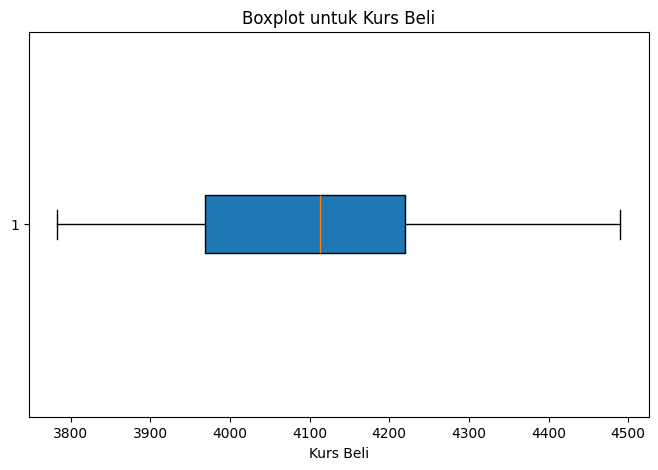

In [ ]:
import matplotlib.pyplot as plt

# Hanya ambil kolom numerik
numerik_kolom = data.select_dtypes(include='number').columns

for col in numerik_kolom:
    plt.figure(figsize=(8, 5))
    plt.boxplot(data[col], vert=False, patch_artist=True)
    plt.title(f"Boxplot untuk {col}")
    plt.xlabel(col)
    plt.show()


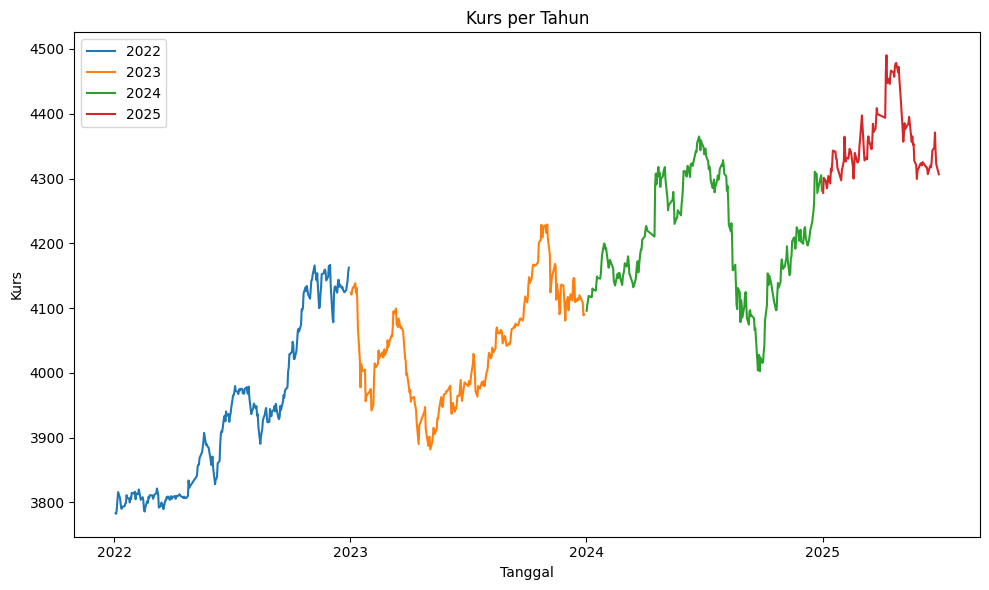

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Misal df sudah terbaca dan ada kolom 'tanggal' serta 'kurs'
data['Tanggal'] = pd.to_datetime(data['Tanggal'])
data['tahun'] = data['Tanggal'].dt.year

plt.figure(figsize=(10, 6))
for tahun in sorted(data['tahun'].unique()):
    data_tahun = data[data['tahun'] == tahun].sort_values(by='Tanggal')  # sort data!
    plt.plot(data_tahun['Tanggal'], data_tahun['Kurs Beli'], label=str(tahun))

plt.title("Kurs per Tahun")
plt.xlabel("Tanggal")
plt.ylabel("Kurs")
plt.legend()

# Format sumbu X agar lebih rapi (hanya tahun)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


In [ ]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# NORMALISASI DAN SPLIT


In [ ]:
# ---------------------------
# 1. Load, sort, split (80:10:10)
# ---------------------------
def load_and_split_801010(path_excel, target_col="Kurs Beli"):
    # Mendefinisikan fungsi dengan nama load_and_split_801010.
    # Parameter path_excel: path atau lokasi file Excel (.xlsx) yang akan dibaca.
    # Parameter target_col: nama kolom target yang ingin digunakan (default: "Kurs Beli").

    df = pd.read_excel(path_excel)  # Membaca file Excel ke dalam DataFrame df.
    if "Tanggal" not in df.columns:
        raise KeyError("Kolom 'Tanggal' tidak ditemukan.")  # Mengecek apakah kolom Tanggal ada dalam dataset. Jika tidak ada, akan muncul error.
    df["Tanggal"] = pd.to_datetime(df["Tanggal"])  # Mengonversi kolom Tanggal menjadi format datetime agar bisa diurutkan secara kronologis.
    df = df.sort_values("Tanggal").reset_index(drop=True)  # Mengurutkan data berdasarkan tanggal dari yang paling awal ke paling akhir, lalu mereset index agar rapi.

    n = len(df)  # Menyimpan panjang (jumlah baris) dari DataFrame ke dalam variabel n.
    train_end = int(n * 0.8)
    val_end = int(n * 0.9)  # 80% + 10%
    # Menentukan indeks akhir untuk data latih (80% dari total data).
    # Menentukan indeks akhir untuk data validasi (80% + 10% = 90%).

    train_df = df.iloc[:train_end].copy()       # data dari awal sampai train_end (80%).
    val_df = df.iloc[train_end:val_end].copy()  # data dari train_end sampai val_end (10% berikutnya).
    test_df = df.iloc[val_end:].copy()          # sisa data (10% terakhir).
    return train_df, val_df, test_df, df  # Mengembalikan train, val, test, dan keseluruhan data (untuk keperluan timestamp/visualisasi).

# ---------------------------
# 2. Scaling (fit only on train)
# ---------------------------
def scale_target(train_df, val_df, test_df, target_col="Kurs Beli"):
    # Mendefinisikan fungsi dengan nama scale_target.
    # Input: 3 subset data (train_df, val_df, test_df) dan nama kolom target (target_col).
    scaler = MinMaxScaler(feature_range=(0, 1))  # Mengubah nilai ke rentang [0, 1].
    y_train_scaled = scaler.fit_transform(train_df[[target_col]])  # Fit+transform pada data latih.
    y_val_scaled   = scaler.transform(val_df[[target_col]])          # Transform validasi dengan skala dari train.
    y_test_scaled  = scaler.transform(test_df[[target_col]])        # Transform uji dengan skala dari train.
    return y_train_scaled, y_val_scaled, y_test_scaled, scaler  # Mengembalikan hasil scaling & objek scaler.

# ---------------------------
# 2.1 Preview Normalisasi (opsional, hanya tampilan)
# ---------------------------
def preview_normalisasi_univariate(
    train_df, val_df, test_df, scaler,
    target_col="Kurs Beli", date_col="Tanggal",
    numbering_col="No", k=3, display_precision=10, clip_for_display=False
):
    """
    Cetak tabel normalisasi per subset:
    - MinMax fit pada TRAIN (anti data leakage)
    - Tambah kolom No 1..N di kiri
    - 3 baris awal + 3 baris akhir
    - Kendalikan presisi tampilan via display_precision
    - (Opsional) clip nilai ke [0,1] hanya untuk TAMPILAN
    """
    import pandas as pd
    import numpy as np

    def _build_scaled_df(sub_df):
        out = sub_df.copy()
        scaled = scaler.transform(sub_df[[target_col]]).reshape(-1).astype(float)
        if clip_for_display:
            scaled = np.clip(scaled, 0.0, 1.0)  # HANYA untuk display
        out[f"{target_col} (scaled 0–1)"] = scaled  # TANPA pembulatan
        out = out.drop(columns=[target_col])
        out = out.reset_index(drop=True)
        out.insert(0, numbering_col, range(1, len(out) + 1))
        cols = [numbering_col]
        if date_col in out.columns:
            cols.append(date_col)
        cols.append(f"{target_col} (scaled 0–1)")
        return out[cols]

    def _head_tail(d):
        if len(d) <= 2 * k:
            return d.copy()
        return pd.concat([d.head(k), d.tail(k)], axis=0)

    def _print_block(title, d):
        # Format kolom scaled pakai presisi khusus (mis. 10 desimal)
        fmt = {f"{target_col} (scaled 0–1)": (lambda x: f"{x:.{display_precision}f}")}
        print("\n===================================================================")
        print("                  Data Normalisasi                      ")
        print("===================================================================\n")
        print(f"--- {title} ---")
        with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
            print(d.to_string(index=False, formatters=fmt))

    # Build tabel hasil scaling per subset
    train_tbl = _build_scaled_df(train_df)
    val_tbl   = _build_scaled_df(val_df)
    test_tbl  = _build_scaled_df(test_df)

    # Info skaler (fit hanya TRAIN)
    print("INFO SKALER (fit hanya pada TRAIN):")
    print(f"- Kolom target       : {target_col}")
    if date_col in train_df.columns:
        print(f"- Kolom tanggal/waktu: {date_col}")
    print(f"- Nilai MIN (TRAIN)  : {float(scaler.data_min_[0])}")
    print(f"- Nilai MAX (TRAIN)  : {float(scaler.data_max_[0])}")

    # Ringkasan jumlah baris
    print("\nJUMLAH BARIS PER SUBSET:")
    print(f"- Train : {len(train_tbl)} (No 1–{len(train_tbl)})")
    print(f"- Val   : {len(val_tbl)} (No 1–{len(val_tbl)})")
    print(f"- Test  : {len(test_tbl)} (No 1–{len(test_tbl)})")

    # Cetak preview
    _print_block("Data Training (3 awal + 3 akhir)", _head_tail(train_tbl))
    _print_block("Data Validasi (3 awal + 3 akhir)", _head_tail(val_tbl))
    _print_block("Data Uji (3 awal + 3 akhir)", _head_tail(test_tbl))

    return {
        "train_scaled_table": train_tbl,
        "val_scaled_table": val_tbl,
        "test_scaled_table": test_tbl,
    }


# ---------------------------
# 3. Lookback builder
# ---------------------------
def buat_lookback(features, target, window):
    # Mendefinisikan fungsi dengan nama buat_lookback.
    # Parameter:
    # features: array fitur input (biasanya hasil scaling juga).
    # target: array target yang ingin diprediksi.
    # window: jumlah langkah waktu (timesteps) untuk input ke model.
    X, y = [], []  # Inisialisasi list kosong untuk menyimpan input (X) dan target/output (y).
    for i in range(len(features) - window):  # Loop dari index 0 sampai len(features) - window.
        X.append(features[i:i+window])       # Mengambil window jumlah data dari features lalu menambahkannya ke X.
        y.append(target[i+window])           # Menambahkan target untuk waktu setelah window selesai, yaitu target[i+window] ke y.
    return np.array(X), np.array(y)          # Mengembalikan input X dan target y sebagai array NumPy.


In [ ]:
# ====== SET PATH & PARAM ======
path_excel = r"./Kurs Transaksi SAR(jan22-jun25) kurs beli.xlsx"  # ganti sesuai lokasi file kamu
target_col = "Kurs Beli"

# ====== 1) LOAD & SPLIT ======
train_df, val_df, test_df, df_all = load_and_split_801010(path_excel, target_col=target_col)

# ====== 2) SCALE (FIT HANYA DI TRAIN) ======
y_train_scaled, y_val_scaled, y_test_scaled, scaler = scale_target(
    train_df, val_df, test_df, target_col=target_col
)

# ====== 3) CETAK TABEL NORMALISASI ======
_ = preview_normalisasi_univariate(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    scaler=scaler,
    target_col="Kurs Beli",
    date_col="Tanggal",
    numbering_col="No",
    k=3,
    display_precision=10,   # ← tampilkan 10 desimal
    clip_for_display=False  # True kalau mau paksa 0..1 untuk tampilannya saja
)



INFO SKALER (fit hanya pada TRAIN):
- Kolom target       : Kurs Beli
- Kolom tanggal/waktu: Tanggal
- Nilai MIN (TRAIN)  : 3782.47
- Nilai MAX (TRAIN)  : 4364.99

JUMLAH BARIS PER SUBSET:
- Train : 665 (No 1–665)
- Val   : 83 (No 1–83)
- Test  : 84 (No 1–84)

                  Data Normalisasi                      

--- Data Training (3 awal + 3 akhir) ---
 No    Tanggal Kurs Beli (scaled 0–1)
  1 2022-01-03           0.0015621781
  2 2022-01-04           0.0000000000
  3 2022-01-05           0.0143857722
663 2024-10-03           0.4454954336
664 2024-10-04           0.5120167548
665 2024-10-07           0.5532857241

                  Data Normalisasi                      

--- Data Validasi (3 awal + 3 akhir) ---
 No    Tanggal Kurs Beli (scaled 0–1)
  1 2024-10-08           0.6370425050
  2 2024-10-09           0.6346563208
  3 2024-10-10           0.6068804505
 81 2025-02-06           0.9334958456
 82 2025-02-07           0.9433152510
 83 2025-02-10           0.9412380691

        

In [ ]:
# === Tabel Ringkas Arsitektur & Jumlah Parameter ===
import pandas as pd # Memanggil pustaka pandas dan memberi alias pd agar mudah bikin tabel (DataFrame).

def count_gru_params(input_size, hidden_size, two_bias=True): # Fungsi untuk menghitung jumlah parameter satu layer GRU
    # input_size (I): banyak fitur yang masuk ke GRU.
    # hidden_size (H): jumlah unit tersembunyi (hidden units).
    # two_bias: True berarti gaya PyTorch (punya dua set bias per gate: untuk input dan recurrent).

    # weights: 3*(I*H + H*H)
    weight = 3 * (input_size * hidden_size + hidden_size * hidden_size) # Implementasi rumus bobot di atas.
    # biases: 3H kalau 1 bias/gate, 6H kalau 2 bias/gate (PyTorch)
    bias = (6 if two_bias else 3) * hidden_size # Hitung total bias sesuai pilihan two_bias.
    return weight + bias # Kembalikan total parameter (bobot + bias).

def count_linear_params(input_size, output_size): # Fungsi untuk menghitung parameter layer Dense.
    # Linear: weight = in*out, bias = out
    # pada Linear, matriks bobot berukuran (output_size, input_size) sehingga jumlah elemennya in*out; bias berukuran (output_size,).
    return input_size * output_size + output_size

# --- Ambil konfigurasi dari kode A-mu ---
# n_features & lookback diambil langsung dari bentuk data windowed agar konsisten:
# Coba ambil jumlah fitur input dari dimensi ketiga X_train_seq (format umum: (batch, lookback, n_features)).
try:
    input_feature_size = int(X_train_seq.shape[2])
except Exception:
    # fallback jika X_train_seq belum tersedia di sel ini
    input_feature_size = 1

# Coba ambil lookback dari dimensi kedua X_train_seq.
try:
    lookback = int(X_train_seq.shape[1])
except Exception:
    # fallback kalau mau pakai opsi pertama di config
    lookback = int(config['lookback_options'][0]) if 'config' in globals() and 'lookback_options' in config else 6

# hidden_sizes: ambil dari variabel yang sudah di pakai
# Cari sumber daftar hidden units per layer dengan prioritas:
# variabel global hidden_sizes jika sudah ada,
# kalau tidak ada, cek di config['hidden_sizes'],
# kalau dua-duanya tidak ada, pakai fallback [256, 128, 64]. Lalu simpan ke hs sebagai list.
if 'hidden_sizes' in globals() and isinstance(hidden_sizes, (list, tuple)):
    hs = list(hidden_sizes)
elif 'config' in globals() and 'hidden_sizes' in config:
    hs = list(config['hidden_sizes'])
else:
    hs = [256, 128, 64]  # fallback aman

linear_output_size = 1  # output kamu 1 nilai (kurs) # Tetapkan ukuran output layer Linear = 1 (prediksi satu angka kurs).

# --- Hitung parameter per layer ---
gru1_params = count_gru_params(input_feature_size, hs[0]) # Hitung total parameter GRU layer 1 (input I = input_feature_size, hidden H = hs[0]).
gru2_params = count_gru_params(hs[0], hs[1]) # GRU layer 2: inputnya sekarang I = hs[0] (keluaran GRU1), hidden H = hs[1].
gru3_params = count_gru_params(hs[1], hs[2]) # GRU layer 3: input I = hs[1], hidden H = hs[2].
linear_params = count_linear_params(hs[2], linear_output_size) # Layer Linear terakhir: input = hs[2], output = 1.

# --- Susun tabel (Output Shape mengikuti alur di modelmu:
#     GRU1/GRU2 keluarkan sequence (batch, lookback, H),
#     GRU3 diambil timestep terakhir -> (batch, H), lalu ke linear -> (batch, 1)) ---
data = {
    "Layer (type)": ["GRU Layer 1", "GRU Layer 2", "GRU Layer 3", "Linear Layer"],
    "Output Shape": [
        f"(None, {lookback}, {hs[0]})",
        f"(None, {lookback}, {hs[1]})",
        f"(None, {hs[2]})",
        f"(None, {linear_output_size})"
    ],
    "Parameters": [gru1_params, gru2_params, gru3_params, linear_params]
}

df_arch = pd.DataFrame(data)
df_arch.loc['Total'] = ['Total', '-', df_arch['Parameters'].sum()]

print("\n===================================================================")
print("                 Arsitektur Model & Jumlah Parameter                ")
print("===================================================================\n")
print(df_arch.to_string(index=False))



                 Arsitektur Model & Jumlah Parameter                

Layer (type)   Output Shape  Parameters
 GRU Layer 1 (None, 6, 256)      198912
 GRU Layer 2 (None, 6, 128)      148224
 GRU Layer 3     (None, 64)       37248
Linear Layer      (None, 1)          65
       Total              -      384449


# MODEL GRU


In [ ]:
# ---------------------------
# 4. GRU architecture
# ---------------------------
class GRUModel(nn.Module): # Membuat kelas model GRU sebagai subclass dari nn.Module (PyTorch).
    def __init__(self, n_features, hidden_sizes, n_outputs=1):
        super(GRUModel, self).__init__()
        # n_features: jumlah fitur input (biasanya 1 untuk univariate).
        # hidden_sizes: list berisi ukuran hidden state untuk tiap lapisan GRU.
        # n_outputs: default 1, karena hanya memprediksi satu nilai (kurs).
        # super() memanggil konstruktor dari nn.Module.

        self.gru1 = nn.GRU(n_features, hidden_sizes[0], batch_first=True)
        self.gru2 = nn.GRU(hidden_sizes[0], hidden_sizes[1], batch_first=True)
        self.gru3 = nn.GRU(hidden_sizes[1], hidden_sizes[2], batch_first=True)
        # Tiga lapisan GRU bertingkat, output dari satu GRU menjadi input ke GRU selanjutnya.
        # batch_first=True: dimensi batch diletakkan di urutan pertama (batch_size, time_step, feature).
        self.fc = nn.Linear(hidden_sizes[2], n_outputs) # Lapisan linear (fully connected) untuk menghasilkan output akhir dari hidden state terakhir.

    def forward(self, x):
        out, _ = self.gru1(x)
        out, _ = self.gru2(out)
        out, _ = self.gru3(out)
        return self.fc(out[:, -1, :])
      # Data dimasukkan ke GRU 1 → GRU 2 → GRU 3.
      # Mengambil output pada timestep terakhir (out[:, -1, :]) → input ke fc → hasil akhir.

# ---------------------------
# 5. Evaluasi: RMSE norm & denorm + MAPE
# ---------------------------
def mean_absolute_percentage_error(y_true, y_pred): # Mendefinisikan fungsi MAPE (evaluasi akurasi prediksi dalam persentase).
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    if not np.any(non_zero):
        return np.nan
    # Menghindari pembagian dengan nol, hanya hitung MAPE jika y_true ≠ 0.
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100 # Rumus MAPE: rata-rata persentase kesalahan absolut.

def evaluasi(loader, model, device, scaler):
    model.eval()
    # Fungsi evaluasi performa model pada data (validasi atau uji).
    # model.eval() → nonaktifkan dropout/batchnorm.
    predictions_norm, true_values_norm = [], []
    with torch.no_grad():
    # Nonaktifkan gradient untuk efisiensi saat inference.
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            # Looping semua batch di loader, kirim ke GPU (jika ada).
            # Hasil model disimpan di output.
            out_np = output.squeeze().cpu().numpy()
            yb_np = yb.squeeze().cpu().numpy()
            # Ubah tensor ke NumPy array untuk evaluasi di luar PyTorch.
            if np.ndim(out_np) == 0:
                predictions_norm.append(float(out_np))
            else:
                predictions_norm.extend(out_np.tolist())
            # Menyesuaikan bentuk data agar semua hasil bisa digabung dalam satu array.

            if np.ndim(yb_np) == 0: # Mengecek apakah yb_np (hasil konversi tensor yb menjadi NumPy) memiliki dimensi 0 (skalar tunggal).
                true_values_norm.append(float(yb_np)) # Jika ya, maka tambahkan nilai tersebut ke list true_values_norm dengan dikonversi menjadi float.
            else:
                true_values_norm.extend(yb_np.tolist()) # Jika yb_np adalah array berdimensi ≥1 (misal: [0.5, 0.6, 0.7]), ubah ke list Python dan gabungkan (extend) ke true_values_norm.

    predictions_norm = np.array(predictions_norm).reshape(-1, 1)
    true_values_norm = np.array(true_values_norm).reshape(-1, 1)
    # Mengatur ulang bentuk array hasil prediksi dan nilai sebenarnya.

    rmse_norm = np.sqrt(np.mean((true_values_norm - predictions_norm) ** 2)) # Hitung RMSE pada data yang masih dinormalisasi.

    y_pred_denorm = scaler.inverse_transform(predictions_norm).flatten()
    y_true_denorm = scaler.inverse_transform(true_values_norm).flatten()
    # Denormalisasi nilai prediksi dan target ke skala asli menggunakan scaler.

    rmse_denorm = np.sqrt(np.mean((y_true_denorm - y_pred_denorm) ** 2))
    mape_denorm = mean_absolute_percentage_error(y_true_denorm, y_pred_denorm)
    # Hitung RMSE dan MAPE pada data yang telah dinormalisasi
    return {
        "rmse_norm": rmse_norm,
        "rmse_denorm": rmse_denorm,
        "mape_denorm": mape_denorm,
        "y_pred_norm": predictions_norm.flatten(),
        "y_true_norm": true_values_norm.flatten(),
        "y_pred_denorm": y_pred_denorm,
        "y_true_denorm": y_true_denorm
    }
    # Kembalikan seluruh metrik evaluasi dan nilai prediksi untuk keperluan plotting/analisis.

# ---------------------------
# 6. Single hyper-run (kombinasi)
# ---------------------------
def kombinasi( # Fungsi untuk melatih 1 kombinasi hyperparameter dan mencatat hasilnya.
    X_train_scaled, y_train_scaled,
    X_val_scaled, y_val_scaled,
    lookback, batch_size, lr,
    hidden_sizes, max_epochs, patience, run_id
               ): # Mendefinisikan fungsi bernama kombinasi.
# Mendefinisikan fungsi bernama kombinasi.
# Parameter:
# X_train_scaled, y_train_scaled: data latih yang telah dinormalisasi.
# X_val_scaled, y_val_scaled: data validasi yang telah dinormalisasi.
# lookback: panjang window untuk membuat data sekuensial.
# batch_size: ukuran batch training.
# lr: learning rate.
# hidden_sizes: list 3 nilai hidden unit GRU.
# max_epochs: maksimal jumlah epoch.
# patience: jumlah epoch tanpa perbaikan sebelum early stopping.
# run_id: ID unik untuk menyimpan model dan log hasil.


    X_train_seq, y_train_seq = buat_lookback(X_train_scaled, y_train_scaled.flatten(), lookback)
    X_val_seq, y_val_seq = buat_lookback(X_val_scaled, y_val_scaled.flatten(), lookback)
    # Membentuk data sekuensial dari data yang telah diskalakan.
    # flatten() mengubah shape target jadi 1 dimensi (dari (n,1) ke (n,)) agar fungsi buat_lookback bisa memproses dengan benar.

    train_ds = TensorDataset(torch.from_numpy(X_train_seq).float(), torch.from_numpy(y_train_seq).float().unsqueeze(1))
    val_ds = TensorDataset(torch.from_numpy(X_val_seq).float(), torch.from_numpy(y_val_seq).float().unsqueeze(1))
    # Mengubah NumPy array menjadi tensor PyTorch (from_numpy).
    # .float() diperlukan karena model dan loss menggunakan tipe float32.
    # .unsqueeze(1) menambahkan dimensi di axis 1 agar target berbentuk [batch_size, 1].

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    # Buat DataLoader untuk training (shuffle=True) dan validasi (shuffle=False).

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Menggunakan device: {device}")

    model = GRUModel(n_features=X_train_seq.shape[2], hidden_sizes=hidden_sizes).to(device) # Inisialisasi model GRU dengan parameter yang diberikan.
    # Inisialisasi model GRU dengan jumlah fitur dari input dan hidden size yang dipilih.
    # .to(device) memindahkan model ke CPU/GPU.

    criterion = nn.MSELoss() # Gunakan Mean Squared Error sebagai fungsi loss.
    optimizer = Adam(model.parameters(), lr=lr) # Gunakan Mean Squared Error sebagai fungsi loss.

    os.makedirs('models', exist_ok=True) # Membuat folder models
    model_path = f'models/model_{run_id}.pth' # Menentukan path file untuk menyimpan model terbaik per kombinasi hyperparameter.

    epoch_results = [] # menyimpan log per epoch.
    best_val_mse = float('inf') # nilai MSE validasi terbaik sejauh ini.
    epochs_no_improve = 0 # penghitung stagnansi perbaikan.
    # Untuk early stopping: menyimpan val RMSE terbaik dan menghitung epoch stagnan

    print(f"\n--- Run {run_id}: lookback={lookback}, batch_size={batch_size}, lr={lr} ---") # Menampilkan info kombinasi hyperparameter yang sedang dilatih.
    for epoch in range(1, max_epochs + 1): # Loop training dari epoch 1 hingga max_epochs (atau berhenti lebih awal via early stopping).
        start = time.time()
        model.train()
        train_loss_accum = 0.0 # Set model ke mode training dan mulai stopwatch.
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device) # Ambil batch input dan target, pindahkan ke device.
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss_value = loss.item()
            loss.backward()
            optimizer.step() # Lakukan forward → hitung loss → backward → update parameter.
            train_loss_accum += loss_value * xb.size(0) # Akumulasi loss per sample untuk menghitung total loss per epoch
        train_mse = train_loss_accum / len(train_loader.dataset)
        train_rmse = np.sqrt(train_mse) # Hitung MSE dan RMSE rata-rata untuk data latih di epoch ini.

        model.eval()
        val_loss_accum = 0.0 # Set model ke mode evaluasi.
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                val_loss_accum += criterion(output, yb).item() * xb.size(0)
                # Evaluasi batch demi batch tanpa menghitung gradien.
                # Hitung loss akumulatif per sample.
        val_mse = val_loss_accum / len(val_loader.dataset) if len(val_loader.dataset) > 0 else float('inf')
        val_rmse = np.sqrt(val_mse)
        # Hitung MSE dan RMSE untuk validasi.

        duration = time.time() - start # Hitung durasi epoch.
        print(f"Epoch {epoch:03d} | Train Loss (MSE): {train_mse:.6f} | Val Loss (MSE): {val_mse:.6f} | "
              f"Train RMSE: {train_rmse:.6f} | Val RMSE: {val_rmse:.6f} | Time: {duration:.2f}s")

        epoch_results.append({
            'run_id': run_id,
            'lookback': lookback,
            'batch_size': batch_size,
            'lr': lr,
            'hidden_sizes': hidden_sizes,
            'epoch': epoch,
            'train_loss': train_mse,
            'val_loss': val_mse,
            'train_rmse': train_rmse,
            'val_rmse': val_rmse,
            'duration_s': duration
        })
        # Simpan informasi per epoch untuk analisis dan visualisasi setelah training selesai.

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path) # Jika RMSE validasi membaik → simpan model → reset counter stagnansi.
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping di epoch {epoch} (tidak ada perbaikan val MSE selama {patience} epoch).")
                break
                # Jika tidak ada perbaikan selama patience epoch → hentikan training lebih awal.

    return epoch_results # Kembalikan list hasil training untuk setiap epoch, akan dipakai untuk plotting atau memilih model terbaik.

# ---------------------------
# 7. Loop tuning
# ---------------------------
def hyperparameter_tuning(train_df, val_df, test_df, full_df, config, target_col="Kurs Beli"):
  # Mendefinisikan fungsi hyperparameter_tuning.
  #Fungsi ini menerima 5 argumen:
  #train_df, val_df, test_df: data latih, validasi, dan uji (masing-masing dalam bentuk DataFrame).
  # full_df: keseluruhan dataset (biasanya digunakan untuk visualisasi nanti).
  # config: dictionary berisi parameter untuk grid search.
  # target_col: nama kolom target yang akan diprediksi, default-nya "Kurs Beli".

    y_train_scaled, y_val_scaled, y_test_scaled, scaler = scale_target(train_df, val_df, test_df, target_col=target_col)
    # Melakukan normalisasi target (kolom "Kurs Beli") pada data latih, validasi, dan uji.
    # Fungsi scale_target mengembalikan target yang sudah dinormalisasi dan juga objek scaler (misalnya MinMaxScaler), yang digunakan untuk inverse scaling nanti.

    X_train_scaled = y_train_scaled
    X_val_scaled = y_val_scaled
    X_test_scaled = y_test_scaled
    # Karena ini kasus univariate time series, maka fitur (X) dan target (y) adalah sama.
    # Jadi X_train_scaled, X_val_scaled, dan X_test_scaled disamakan dengan y_*_scaled.

    all_results = []
    run_count = 0
    # all_results akan menyimpan seluruh hasil dari setiap kombinasi hyperparameter (per epoch).
    # run_count digunakan untuk memberi nomor pada setiap kombinasi (run).

    for lookback in config['lookback_options']:
        for batch_size in config['batch_size_options']:
            for lr in config['lr_options']:
              # Melakukan iterasi untuk setiap kombinasi dari:
              # lookback (panjang jendela sekuensial),
              # batch_size,
              # learning_rate.
              # Nilai-nilai ini diambil dari config dictionary.

                run_count += 1
                run_id = f"{run_count:03d}"
                # Menambah counter untuk run ke-berapa.
                # run_id adalah ID yang diformat dalam 3 digit (misal "001", "002"), digunakan untuk menamai model file dan tracking hasil.
                res = kombinasi(
                    X_train_scaled, y_train_scaled,
                    X_val_scaled, y_val_scaled,
                    lookback=lookback,
                    batch_size=batch_size,
                    lr=lr,
                    hidden_sizes=config['hidden_sizes'],
                    max_epochs=config['max_epochs'],
                    patience=config['patience'],
                    run_id=run_id
                ) # Memanggil fungsi kombinasi untuk menjalankan 1 eksperimen dengan hyperparameter tertentu.
                  # kombinasi akan melatih model GRU, melakukan validasi, dan mencatat hasilnya.
                all_results.extend(res) # Menambahkan semua hasil (per epoch) dari satu run ke list all_results.
    results_df = pd.DataFrame(all_results) # Mengubah list hasil seluruh run menjadi DataFrame untuk analisis lebih lanjut (misal plotting atau pemilihan model terbaik).
    return results_df, X_test_scaled, y_test_scaled, full_df, scaler
    # Mengembalikan:
    # results_df: hasil tuning per epoch per run,
    # X_test_scaled, y_test_scaled: data uji yang sudah dinormalisasi,
    # full_df: seluruh data mentah (biasanya untuk visualisasi hasil prediksi),
    # scaler: objek normalisasi untuk digunakan kembali saat denormalisasi nilai prediksi.

# ---------------------------
# 8. Pilih terbaik & evaluasi
# ---------------------------
def pilih_model_terbaik_and_evaluate(results_df, X_test_scaled, y_test_scaled, full_df, scaler):
  # Definisi fungsi untuk memilih model terbaik dari hasil tuning, kemudian menggunakannya untuk evaluasi di data uji.
  # results_df: DataFrame berisi hasil tuning semua kombinasi hyperparameter.
  # X_test_scaled, y_test_scaled: Data uji yang telah dinormalisasi.
  # full_df: Data mentah (penuh) yang dipakai untuk mengembalikan tanggal asli.
  # scaler: Objek MinMaxScaler yang dipakai untuk denormalisasi.

    best_row = results_df.loc[results_df['val_loss'].idxmin()] # Ambil baris model dengan RMSE validasi terkecil dari results_df.
    best_params = best_row.to_dict() # Ubah informasi model terbaik menjadi dictionary (best_params) untuk digunakan nanti.
    run_id = best_row['run_id']
    lookback = int(best_row['lookback'])
    batch_size = int(best_row['batch_size'])
    # Ambil nilai run_id, lookback, dan batch_size dari model terbaik.

    print("\n=== Model Terbaik ===")
    print(f"Run ID: {run_id}")
    print(f"Lookback: {lookback}, Batch Size: {batch_size}, LR: {best_row['lr']}, Hidden Sizes: {best_row['hidden_sizes']}")
    print(f"Validation Loss (MSE) Terbaik : {best_row['val_loss']:.6f} (epoch {best_row['epoch']})")
    print(f"Validation RMSE (padanan)     : {np.sqrt(best_row['val_loss']):.6f} (epoch {best_row['epoch']})")    # Menampilkan informasi detail mengenai konfigurasi dari model terbaik.

    X_test_seq, y_test_seq = buat_lookback(X_test_scaled, y_test_scaled.flatten(), lookback) # Bangun input data sekuensial (dengan sliding window) dari data test berdasarkan lookback.
    test_ds = TensorDataset(torch.from_numpy(X_test_seq).float(), torch.from_numpy(y_test_seq).float().unsqueeze(1))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    #Konversi data test ke dalam bentuk TensorDataset dan DataLoader untuk evaluasi model batch per batch.

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GRUModel(n_features=X_test_seq.shape[2], hidden_sizes=best_row['hidden_sizes']).to(device) # Inisialisasi ulang model GRU dengan parameter hidden_sizes yang digunakan saat training terbaik.
    model_path = f"models/model_{run_id}.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    # Load bobot model GRU terbaik dari file .pth yang sebelumnya disimpan.

    eval_dict = evaluasi(test_loader, model, device, scaler) # Panggil fungsi evaluasi untuk menghitung prediksi dan metrik evaluasi (RMSE, MAPE, dll).

    total_len = len(full_df)
    test_start_idx = int(total_len * 0.9) # menghitung indeks awal dari data uji (testing set), dilakukan mulai dari 90% terakhir dari keseluruhan data.
    tanggal_pred = full_df["Tanggal"].iloc[test_start_idx + lookback:].reset_index(drop=True)

    pred_df = pd.DataFrame({
        "Tanggal": tanggal_pred,
        "Kurs_Asli_Scaled": eval_dict["y_true_norm"],
        "Kurs_Prediksi_Scaled": eval_dict["y_pred_norm"],
        "Kurs_Asli": eval_dict["y_true_denorm"],
        "Kurs_Prediksi": eval_dict["y_pred_denorm"],
    }) # Susun semua hasil prediksi dan nilai asli (baik yang sudah dinormalisasi dan yang sudah dikembalikan ke skala asli) ke dalam DataFrame.

    metrics = {
        "rmse_norm": eval_dict["rmse_norm"],
        "rmse_denorm": eval_dict["rmse_denorm"],
        "mape_denorm": eval_dict["mape_denorm"]
    } # Simpan metrik RMSE dan MAPE ke dalam dictionary metrics.

    return best_params, metrics, pred_df
    # Kembalikan:
    # best_params: konfigurasi hyperparameter terbaik
    # metrics: nilai evaluasi model terbaik
    # pred_df: hasil prediksi dalam bentuk DataFrame

# ---------------------------
# 9. Visualisasi Loss (MSE) per Run dengan Titik Merah di Val Loss Terbaik
# ---------------------------
def visualize_mse_loss_per_run(results_df): # Mendefinisikan fungsi dengan argumen results_df, yaitu DataFrame yang menyimpan hasil tiap epoch dari semua percobaan model.
    for run_id in sorted(results_df['run_id'].unique()): # Melakukan loop untuk setiap run_id unik (kombinasi hyperparameter yang berbeda). Disortir agar urut berdasarkan ID run.
        run_data = results_df[results_df['run_id'] == run_id] # Memfilter data hanya untuk satu run_id (satu percobaan model).

        plt.figure(figsize=(10,4)) #Membuat plot baru berukuran 10x4 inci.
        plt.plot(run_data['epoch'], run_data['train_loss'], label='Train Loss (MSE)', color='royalblue')
        plt.plot(run_data['epoch'], run_data['val_loss'], label='Validation Loss (MSE)', color='darkorange')
        # Memplot kurva MSE loss untuk train dan validation pada setiap epoch.

        # Titik merah pada validation loss (MSE) minimum
        min_val_loss_row = run_data.loc[run_data['val_loss'].idxmin()] # Mengambil baris di mana validation loss mencapai nilai terendah.
        plt.scatter(min_val_loss_row['epoch'], min_val_loss_row['val_loss'], color='red',
                    label=f"Best Val Loss {min_val_loss_row['val_loss']:.4f}")
        # Menambahkan titik merah pada titik val_loss terendah (terbaik) sebagai penanda performa terbaik.

        plt.title(f"Loss (MSE) Curve - Run {run_id}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss (MSE)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        # Menambahkan judul, label, legend, grid, dan menampilkan grafik.

def visualize_prediction_scaled_and_denorm(pred_df): # Mendefinisikan fungsi dengan argumen pred_df, yaitu DataFrame yang berisi hasil prediksi dan data aktual baik dalam bentuk scaled maupun denorm.
    plt.figure(figsize=(14,5))
    plt.plot(pred_df['Tanggal'], pred_df['Kurs_Asli_Scaled'], label='Kurs Aktual (scaled)')
    plt.plot(pred_df['Tanggal'], pred_df['Kurs_Prediksi_Scaled'], label='Kurs Prediksi (scaled)')
    plt.title("Perbandingan Kurs Aktual vs Prediksi (Skala Normalisasi)")
    plt.xlabel("Tanggal")
    plt.ylabel("Kurs Beli (scaled)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # Membuat plot untuk membandingkan data aktual dan prediksi dalam skala yang sudah dinormalisasi (biasanya antara 0 dan 1).
    # Sumbu x = Tanggal; y = nilai kurs yang sudah diskalakan.
    # Berguna untuk melihat performa model tanpa pengaruh skala asli data.

    plt.figure(figsize=(14,5))
    plt.plot(pred_df['Tanggal'], pred_df['Kurs_Asli'], label='Kurs Aktual')
    plt.plot(pred_df['Tanggal'], pred_df['Kurs_Prediksi'], label='Kurs Prediksi')
    plt.title("Perbandingan Kurs Aktual vs Prediksi (Denormalisasi)")
    plt.xlabel("Tanggal")
    plt.ylabel("Kurs Beli")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # Menampilkan kurva hasil prediksi setelah dikembalikan ke skala asli (denormalisasi).
    # Lebih mudah diinterpretasikan karena menunjukkan nilai kurs sebenarnya.

# ---------------------------
# 10. Visualisasi split data
# ---------------------------
def visualize_splits(train_df, val_df, test_df):
    plt.figure(figsize=(14,5))
    plt.plot(train_df["Tanggal"], train_df["Kurs Beli"], label="Pelatihan", linewidth=1)
    plt.plot(val_df["Tanggal"], val_df["Kurs Beli"], label="Validasi", linewidth=1)
    plt.plot(test_df["Tanggal"], test_df["Kurs Beli"], label="Uji", linewidth=1)
    split1 = train_df["Tanggal"].iloc[-1]
    split2 = val_df["Tanggal"].iloc[-1]
    plt.axvline(split1, color="black", linestyle="--", alpha=0.6)
    plt.axvline(split2, color="black", linestyle="--", alpha=0.6)
    plt.title("Pembagian Data: Pelatihan / Validasi / Uji (80:10:10)")
    plt.xlabel("Tanggal")
    plt.ylabel("Kurs Beli")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # Fungsi visualize_splits() untuk menampilkan pembagian dataset time series ke dalam subset train, validation, dan test.

# ---------------------------
# 11. Tampilkan sederhana aktual vs prediksi
# ---------------------------
def tampilkan_perbandingan_simpel(pred_df, n=5): # Fungsi dengan argumen pred_df (DataFrame hasil prediksi) dan n jumlah baris awal/akhir yang ingin ditampilkan (default 5).
    comp = pred_df[["Tanggal", "Kurs_Asli", "Kurs_Prediksi"]].copy() # Membuat salinan dari kolom yang relevan: tanggal, nilai kurs asli, dan hasil prediksi.
    comp["Kurs_Asli"] = comp["Kurs_Asli"].round(6)
    comp["Kurs_Prediksi"] = comp["Kurs_Prediksi"].round(6)
    # Membulatkan angka kurs hingga 6 angka di belakang koma agar lebih rapi.

    print("\n--- Perbandingan Nilai Aktual dan Prediksi ---") # Menampilkan header di terminal atau output konsol.
    print(f"\n{n} Baris Data Awal:") # Menampilkan n baris pertama tanpa indeks.
    print(comp.head(n).to_string(index=False))
    print(f"\n{n} Baris Data Akhir:")
    print(comp.tail(n).to_string(index=False))
    # Menampilkan n baris terakhir tanpa indeks.

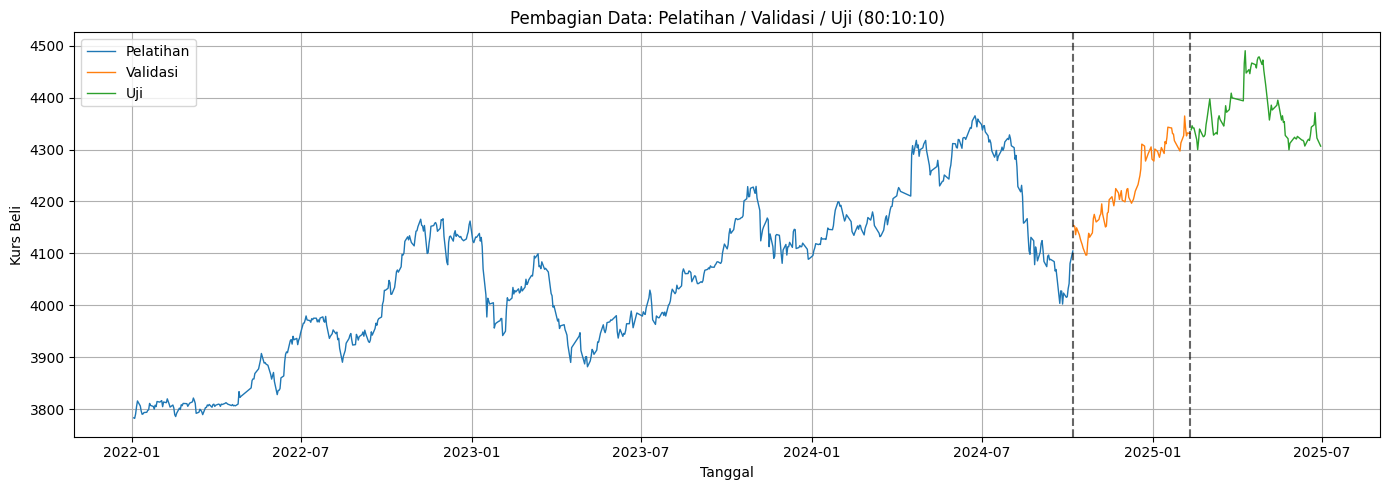

Menggunakan device: cpu

--- Run 001: lookback=6, batch_size=8, lr=0.001 ---
Epoch 001 | Train Loss (MSE): 0.024575 | Val Loss (MSE): 0.002490 | Train RMSE: 0.156764 | Val RMSE: 0.049896 | Time: 1.46s
Epoch 002 | Train Loss (MSE): 0.002479 | Val Loss (MSE): 0.003452 | Train RMSE: 0.049788 | Val RMSE: 0.058755 | Time: 1.34s
Epoch 003 | Train Loss (MSE): 0.002473 | Val Loss (MSE): 0.001599 | Train RMSE: 0.049730 | Val RMSE: 0.039988 | Time: 1.35s
Epoch 004 | Train Loss (MSE): 0.002215 | Val Loss (MSE): 0.001471 | Train RMSE: 0.047067 | Val RMSE: 0.038357 | Time: 1.33s
Epoch 005 | Train Loss (MSE): 0.002208 | Val Loss (MSE): 0.002383 | Train RMSE: 0.046991 | Val RMSE: 0.048820 | Time: 1.35s
Epoch 006 | Train Loss (MSE): 0.001875 | Val Loss (MSE): 0.005372 | Train RMSE: 0.043297 | Val RMSE: 0.073293 | Time: 1.39s
Epoch 007 | Train Loss (MSE): 0.002022 | Val Loss (MSE): 0.002826 | Train RMSE: 0.044969 | Val RMSE: 0.053160 | Time: 1.89s
Epoch 008 | Train Loss (MSE): 0.001910 | Val Loss (MSE)

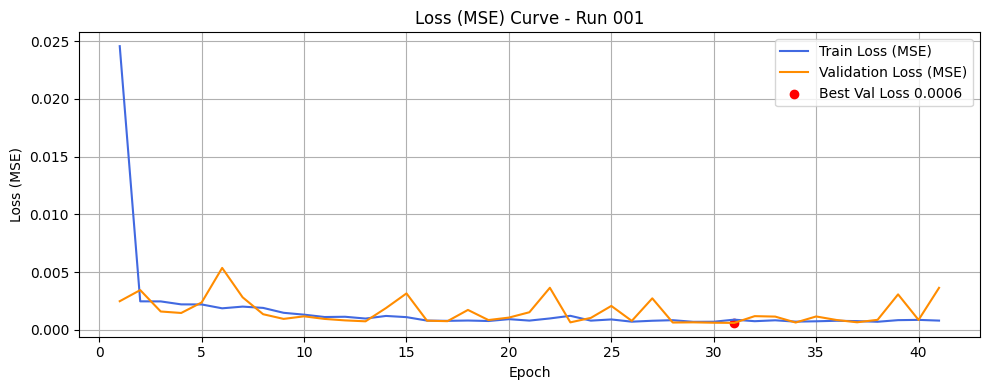

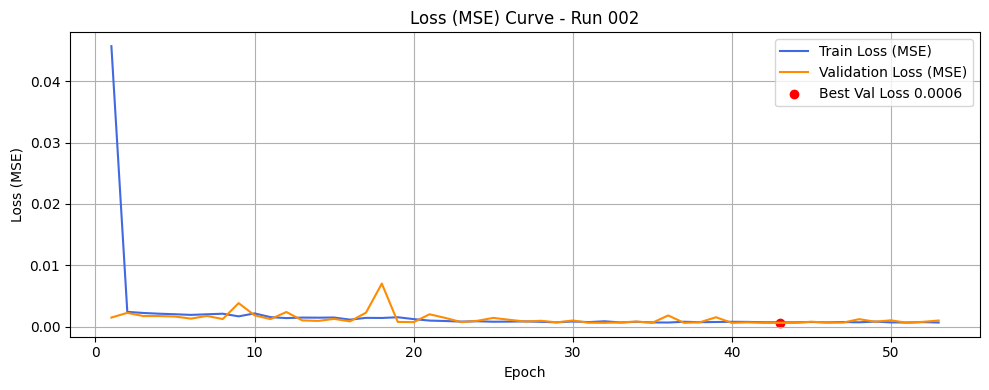

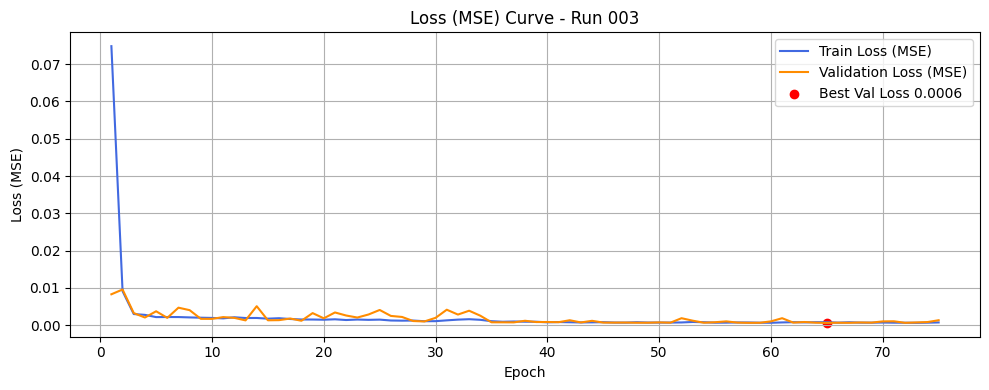

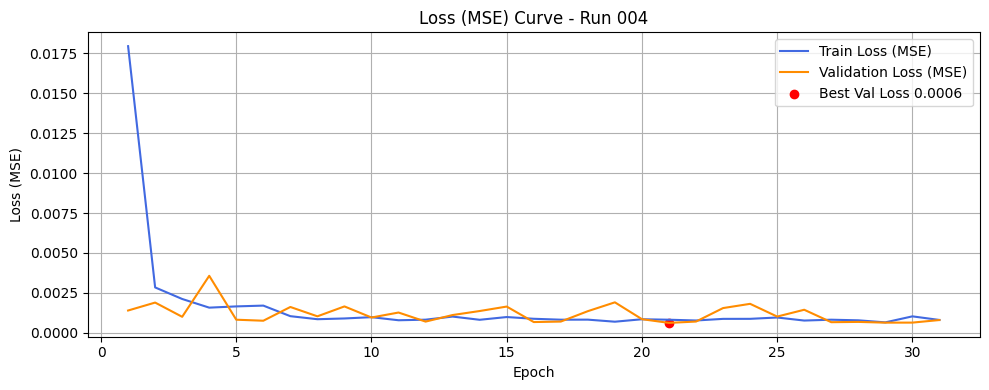

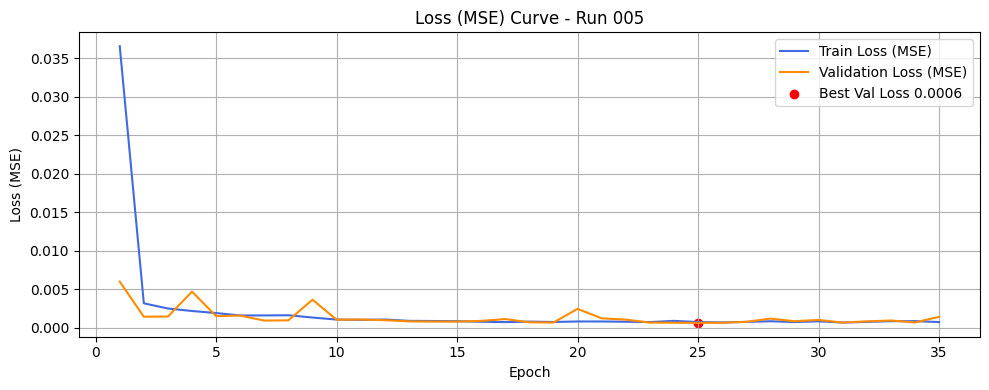

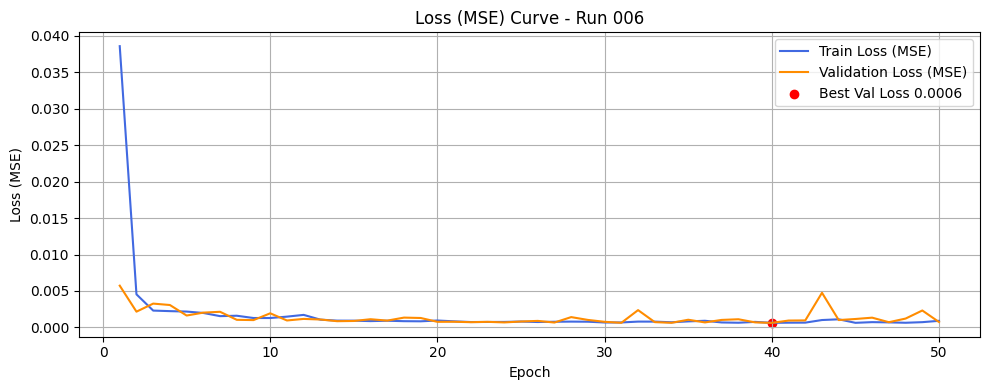

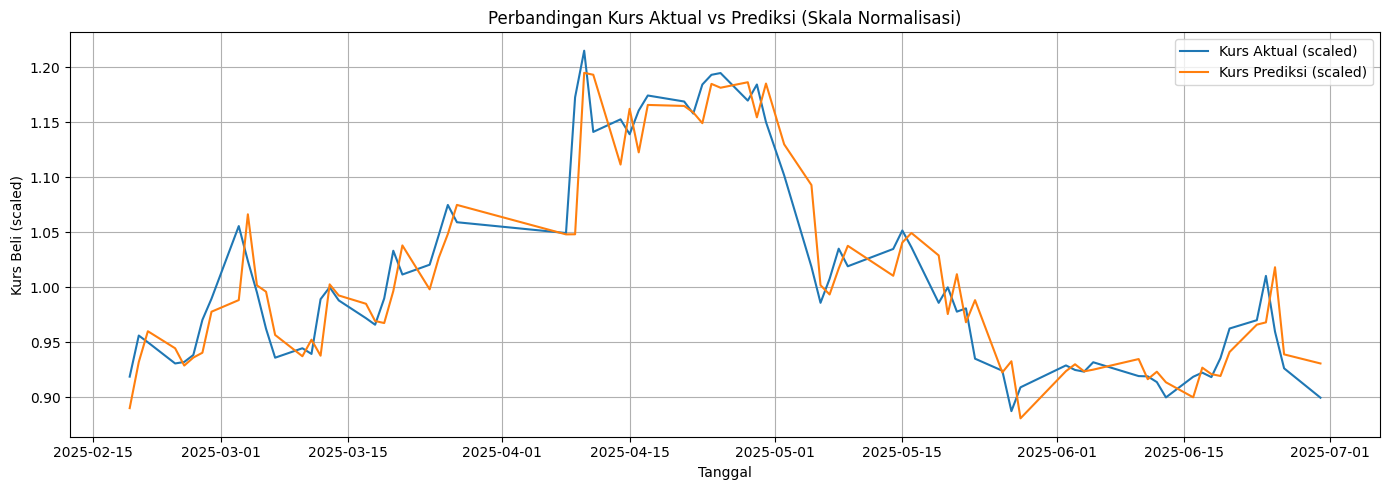

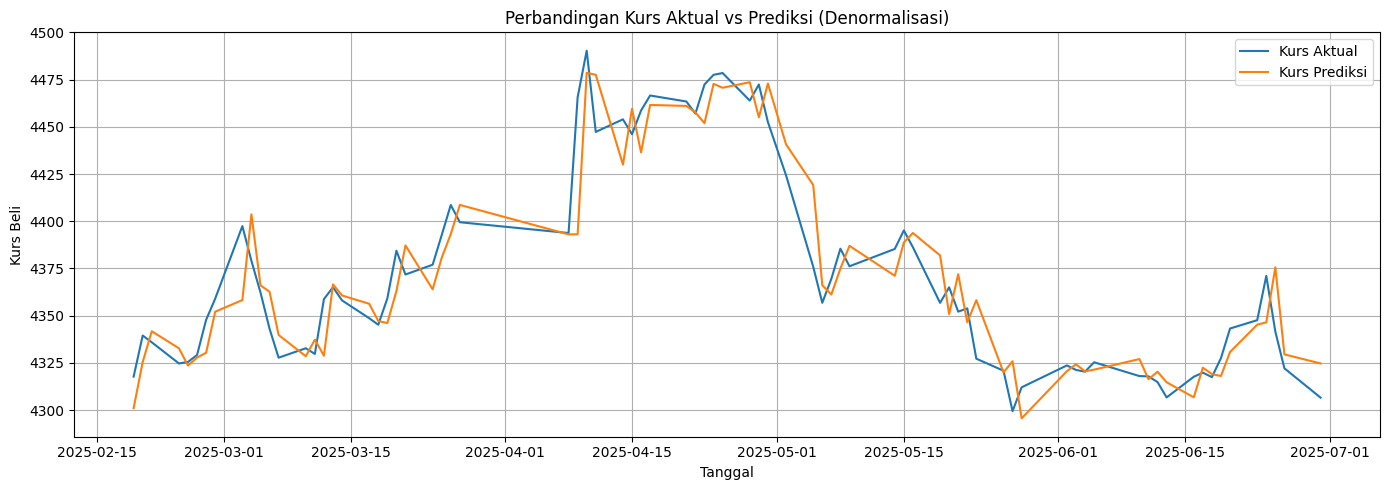

In [ ]:
# ---------------------------
# 12. Main
# ---------------------------
if __name__ == "__main__": # Memastikan kode hanya dieksekusi jika file dijalankan langsung (bukan diimpor sebagai modul).
    config = {
        'lookback_options': [6, 12],
        'batch_size_options': [8, 16, 32],
        'lr_options': [0.001],
        'hidden_sizes': (256, 128, 64),
        'max_epochs': 100,
        'patience': 10
    }
    # Konfigurasi hyperparameter untuk tuning:
    # lookback_options: panjang jendela input time series (6 dan 12 hari).
    # batch_size_options: ukuran batch untuk training.
    # lr_options: learning rate (di sini hanya 0.001).
    # hidden_sizes: jumlah unit pada 3 lapisan tersembunyi GRU.
    # max_epochs: maksimal epoch training per kombinasi.
    # patience: early stopping jika val loss tidak membaik.

    path_excel = "/content/Kurs Transaksi SAR(jan22-jun25) kurs beli.xlsx" # Path ke file Excel data kurs beli.
    train_df, val_df, test_df, full_df = load_and_split_801010(path_excel, target_col="Kurs Beli") # Memanggil fungsi pembagi data dengan rasio 80:10:10 berdasarkan waktu (time series split).

    visualize_splits(train_df, val_df, test_df) # Visualisasi hasil pembagian train/val/test dengan garis pemisah.

    results_df, X_test_scaled, y_test_scaled, full_df, scaler = hyperparameter_tuning(
        train_df, val_df, test_df, full_df, config, target_col="Kurs Beli"
    )
    # Melakukan pelatihan model GRU untuk semua kombinasi hyperparameter dari config.
    # Mengembalikan:
    # results_df: performa semua kombinasi
    # X_test_scaled, y_test_scaled: data uji yang sudah diskalakan
    # scaler: untuk denormalisasi nanti

    best_params, metrics, pred_df = pilih_model_terbaik_and_evaluate(
        results_df, X_test_scaled, y_test_scaled, full_df, scaler
    )
    # Menentukan kombinasi model terbaik berdasarkan val loss terendah.
    # Menghasilkan metrik evaluasi (RMSE, MAPE) dan dataframe prediksi (pred_df).

    print("\n--- Evaluasi pada Data Uji ---")
    print(f"RMSE (skala normalisasi): {metrics['rmse_norm']:.6f}")
    print(f"RMSE (denormalisasi): {metrics['rmse_denorm']:.6f}")
    print(f"MAPE (denormalisasi): {metrics['mape_denorm']:.4f}%")
    # Menampilkan hasil evaluasi model pada data uji, baik sebelum dan sesudah denormalisasi.

    tampilkan_perbandingan_simpel(pred_df, n=5)
    # Menampilkan 5 baris pertama dan terakhir perbandingan nilai aktual dan prediksi kurs beli.

    pred_df.to_csv("perbandingan_prediksi_kurs_beli.csv", index=False)
    print("Prediksi disimpan ke 'perbandingan_prediksi_kurs_beli.csv'")
    # Menyimpan hasil prediksi dan nilai aktual ke file CSV untuk referensi atau analisis lanjut.

    visualize_mse_loss_per_run(results_df) # Menampilkan grafik loss (MSE) per epoch untuk tiap kombinasi hyperparameter.
    visualize_prediction_scaled_and_denorm(pred_df) # Menampilkan grafik prediksi vs aktual (dalam versi skala normalisasi dan denormalisasi).